# JAX for high-performance GPU computing

This notebook is a short tutorial introducing the core ideas behind JAX and the main reasons it is useful for numerical computing.

By the end, you should have a practical understanding of:

- how JAX handles arrays
- how random numbers are generated in JAX
- how GPU acceleration changes performance
- how `jit`, `grad`, and `vmap` fit into the workflow

JAX combines three key ideas that make it especially powerful for scientific and machine-learning workloads:

- just-in-time compilation (`jit`)
- automatic differentiation (`grad`)
- accelerated linear algebra (`xla`)

In [52]:
import jax.numpy as jnp
import numpy as np
from jax import grad, jit, vmap
from jax import random
import matplotlib.pyplot as plt

## Arrays and JAX data structures

JAX arrays behave a lot like NumPy arrays. They support the same basic operations such as indexing, slicing, reshaping, arithmetic, and broadcasting.

The main difference is that JAX arrays are designed to work naturally with compiled numerical code and accelerator hardware. In other words, they are not just a cosmetic reimplementation of NumPy; they are built for high-performance computation.

Let’s start by comparing a standard NumPy array with a JAX array to see the similarities and the practical differences.

In [53]:
np.zeros((3, 3))

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [54]:
jnp.zeros((3, 3))

Array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float32)

## Random numbers in JAX

Random number generation in JAX is slightly different from NumPy because JAX uses explicit pseudo-random keys rather than a single shared global random state.

This design makes random generation more reproducible and easier to reason about in compiled, batched, or distributed code. Instead of mutating a global generator, we create a key and pass it explicitly to the random function we want to use.

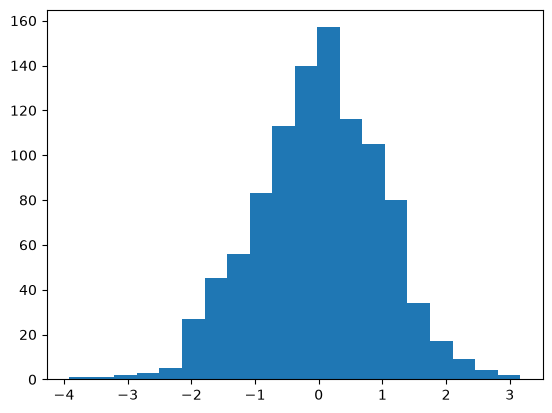

In [55]:
key = random.PRNGKey(0)
x = random.normal(key, (1000,))
plt.hist(x, bins=20)
plt.show()

## Performance: matrix multiplication on the GPU

One of the main reasons to use JAX is its ability to run large numerical operations efficiently, especially when the computation is offloaded to a GPU or other accelerator.

A dense matrix multiplication is a good example because it is both common and computationally heavy. We can compare the performance of JAX against standard NumPy to see the practical difference.

In [56]:
size = 3000
x = random.normal(key, (size,size), dtype = jnp.float32)
%timeit jnp.dot(x, x.T).block_until_ready()  # runs on the GPU

80.4 ms ± 3.33 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [57]:
y = np.random.rand(size, size)
%timeit np.dot(y, y.T)

616 ms ± 94 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


This comparison is useful because JAX NumPy functions can also accept ordinary NumPy arrays. However, when that happens, JAX usually has to move the data onto the device before the computation can run.

That cost of transfer can dominate the total runtime for small or medium-sized arrays. In practice, it is much more efficient to create or convert arrays in JAX format before running large numerical operations.

In [58]:
from jax._src.api import block_until_ready

In [59]:
x = np.random.normal(size = (size,size)).astype(np.float32)
%timeit jnp.dot(x, x.T).block_until_ready()

85.1 ms ± 3.07 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


This is slower because every call must copy data from the CPU to the GPU before the computation begins. A simple way to reduce that overhead is to move the array to the device once using `device_put()`.

The result still behaves like a JAX array, but it remains on the accelerator until it is explicitly needed on the host for printing, plotting, saving, or branching logic.

In [60]:
from jax import device_put

In [61]:
x = np.random.normal(size = (size,size)).astype(np.float32)
x = device_put(x)
%timeit jnp.dot(x, x.T).block_until_ready()

80.6 ms ± 3.58 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Core JAX transformations

JAX is much more than a GPU-backed version of NumPy. It includes a small set of core transformations that are especially useful in numerical computing.

These are the three most important ones to understand first:

- `jit()`: compiles a function so it can run efficiently
- `grad()`: automatically computes derivatives
- `vmap()`: applies a function across array batches or dimensions

These tools often work together in real workflows. For example, you might compile a function with `jit`, differentiate it with `grad`, and batch operations with `vmap` to process many inputs at once. We’ll explore each of these in turn.

## `jit`

`jit` stands for just-in-time compilation. In JAX, it takes a Python function and compiles it into a more efficient executable form, usually for the device you are running on (CPU, GPU, or TPU).

Typical pattern:

```python
from jax import jit

@jit
def f(x):
    return x ** 2 + 3 * x + 1
```

JAX traces the function once, builds an optimized computation graph, and reuses that compiled version on later calls. Useful for:
- numerical kernels
- loops with heavy repeated array operations
- scientific computing and optimization routines

Important note:
- `jit` is best for pure functions with array inputs and no side effects
- it works best when the shapes and types are consistent across calls

In [62]:
# Natively
def foo_bar(x, a = 1.67, b = 1.05):
  return a * jnp.where(x>0, x, b * jnp.exp(x) - a)

x = random.normal(key, (10000000,))
%timeit foo_bar(x).block_until_ready()

21.6 ms ± 395 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [63]:
@jit
def foo_bar(x, a = 1.67, b = 1.05):
  return a * jnp.where(x>0, x, b * jnp.exp(x) - a)

x = random.normal(key, (10000000,))
%timeit foo_bar(x).block_until_ready()

5.09 ms ± 35 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## `grad`

`grad` is JAX’s automatic differentiation tool. It takes a function and returns a new function that computes the derivative of the original output with respect to one or more inputs.

Typical pattern:

```python
from jax import grad

def f(x):
    return x**3 + 2*x**2 + 5

dfdx = grad(f)
dfdx(3.0)
```

gives the derivative at $x = 3$:

$$
\frac{d}{dx}(x^3 + 2x^2 + 5)|_{x=3} ( = 3x^2 + 4x ) = 39
$$

No manual derivation required and works well with arrays and numerical optimization.
- `grad` differentiates with respect to the first positional argument by default
- if you want higher-order derivatives, you can compose `grad` again
- it works best with functions that are differentiable and written in JAX-friendly NumPy code

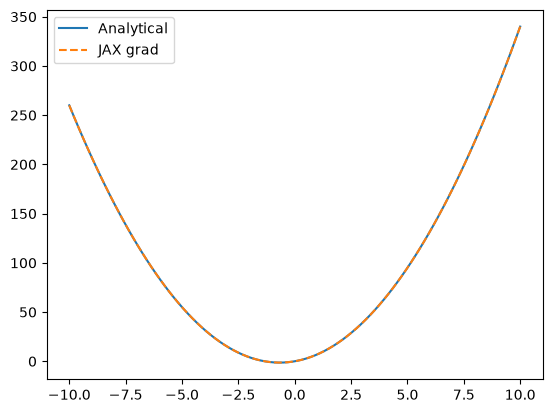

In [64]:
f = lambda x: jnp.sum(x**3 + 2*x**2 + 5)
analytic_dfdx = lambda x: 3*x**2 + 4*x

jnp_dfdx = grad(f)

x = jnp.linspace(-10, 10, 100)
y_analytic = analytic_dfdx(x)
y_jnp = jnp_dfdx(x)
plt.plot(x, y_analytic, label='Analytical')
plt.plot(x, y_jnp, "--", label='JAX grad')
plt.legend()
plt.show()

## Why `jnp.sum` is needed

Because `grad` in JAX is defined for scalar-valued functions only.

If you write a function like this:

```python
def f(x):
    return x**2
```

then `f(x)` is a scalar when `x` is a scalar, so it works fine.

But if you write:

```python
def f(x):
    return x**2 + 2*x
```

and `x` is an array like:

```python
x = jnp.linspace(-10, 10, 100)
```

then the function returns an array of length 100, not a single number. JAX sees that as a vector-valued output, and `grad` refuses to differentiate it because the derivative of a vector-valued function is a Jacobian, not a single gradient.

So to use `grad`, we reduce the output to one scalar with something like:

```python
jnp.sum(x**2 + 2*x)
```

This turns the array into a single number, and then JAX can compute the derivative of that scalar quantity with respect to `x`.

In other words:

- `grad` wants a single number to differentiate
- `sum` is just a way to collapse an array into one scalar
- this matches the mathematical idea of differentiating a scalar objective

A good mental model is:

```python
loss = jnp.sum(model_output - target)**2
gradient = grad(loss)
```

That is exactly how optimisation works: you define a scalar loss, then differentiate that loss.

For more advanced automatic differentiation, JAX gives you two useful tools:

- `jax.vjp()` computes a reverse-mode vector-Jacobian product
- `jax.jvp()` computes a forward-mode Jacobian-vector product

These are helpful when you want to differentiate functions that return vectors or when you want to propagate sensitivities in a chosen direction.

For example, you can compose these operations to create a function that efficiently computes a full Hessian matrix, which is the matrix of second derivatives of a scalar function.

## `vmap`

`vmap` stands for vectorized map. It lets you apply the same function to each element of a batch without writing a Python loop.

Instead of doing something like:

```python
results = []
for x in xs:
    results.append(f(x))
```

you can write:

```python
from jax import vmap

results = vmap(f)(xs)
```

This is especially useful when your data naturally comes in batches. 

In [65]:
def f(x):
    return x**2 + 1

xs = jnp.array([1.0, 2.0, 3.0])
vmap(f)(xs)

Array([ 2.,  5., 10.], dtype=float32)